# Two-island Model på Baboon data 

I denne notebook analyserer jeg genetiske data fra bavianer (*papio*) med en two-island model.

Two island model bygger på to populationer (øer):

- Har eksisteret længe uden split i modellen
- Udveksler migration konstant

Modelstruktur:

pop1 $\leftrightarrow$ pop2

Ingen ancestral population i modellen (i modsætning til IM model).

In [1]:
# Importer nødvendige pakker
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, ExpStepSize, ExpRegularization,
    StateIndexer, Property, PropertySet, set_log_level
)
set_log_level('WARNING')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import sgkit as sg
%config InlineBackend.figure_format = 'svg'
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme

all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')


## 1. Validering på simulerede data

Som i Notebook 05 starter jeg med simulerede data med kendte parametre for at verificere implementationen.

In [2]:
import msprime

def derived_counts(ts, rec_rate):
    records = []
    for var in ts.variants():
        p, g = var.site.position, var.genotypes
        records.append((int(p), p*rec_rate, g.sum()))
    df = pd.DataFrame().from_records(
        records, columns=["pos", "gen_pos", "count"]
        )
    return df

# Sande parametre for simulering 
mut_rate = 5e-10
rec_rate = 1e-8
nr_samples = 5
seq_length = 100_000_000
pop1_size, pop2_size, anc_pop_size = 20_000, 10_000, 15_000
migr_pop1_to_pop2 = 1e-4
migr_pop2_to_pop1 = 5e-4

# Simuler island-model med msprime
demography = msprime.Demography()
demography.add_population(name="pop1", initial_size=pop1_size)
demography.add_population(name="pop2", initial_size=pop2_size)
demography.set_migration_rate(source="pop1", dest="pop2", rate=migr_pop1_to_pop2)
demography.set_migration_rate(source="pop2", dest="pop1", rate=migr_pop2_to_pop1)
ts = msprime.sim_ancestry(samples={"pop1": nr_samples, "pop2": 0}, ploidy=1, 
                          demography=demography, recombination_rate=rec_rate, 
                          sequence_length=seq_length, random_seed=12)
ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=5678)
df = derived_counts(ts, rec_rate)
df.to_csv("island_model_derived_counts.csv", index=False)


In [3]:
def pairs_in_range(nums, diff_lo, diff_hi):
    """
    Find alle SNP-par med fysisk afstand i intervallet [diff_lo, diff_hi].
    Returnerer liste af indeks-par.
    """
    n = len(nums)
    lo, hi = 1, 1
    pairs = []
    for i in range(n):
        if lo <= i:
            lo = i + 1
        while lo < n and nums[lo] - nums[i] < diff_lo:
            lo += 1
        if hi <= i:
            hi = i + 1
        while hi < n and nums[hi] - nums[i] <= diff_hi:
            hi += 1
        for j in range(lo, hi):
            pairs.append((i, j))
    return pairs


df = pd.read_csv("island_model_derived_counts.csv")

col = "pos" # can also use "gen_pos"
distance, tolerance = 5000, 500
min_dist, max_dist = distance - tolerance, distance + tolerance
records = []
for i, j in pairs_in_range(df[col].values, min_dist, max_dist):
    records.append((df.at[i, col], df.at[j, col], df.at[i, "count"], df.at[j, "count"]))
pairs = pd.DataFrame.from_records(records, columns=["pos1", "pos2", "count1", "count2"])
pairs.head()

,pos1,pos2,count1,count2
0,160020,164783,1,3
1,307248,311878,4,1
2,516495,521242,2,1
3,948820,953791,1,3
4,1784175,1788903,1,1


In [4]:
#Fjern overlappende par (par der deler et SNP)
mask = (pairs.pos1 == pairs.pos1.shift()) | (pairs.pos2 == pairs.pos2.shift())
filtered_pairs = pairs.loc[~mask, :]
filtered_pairs.head()

,pos1,pos2,count1,count2
0,160020,164783,1,3
1,307248,311878,4,1
2,516495,521242,2,1
3,948820,953791,1,3
4,1784175,1788903,1,1


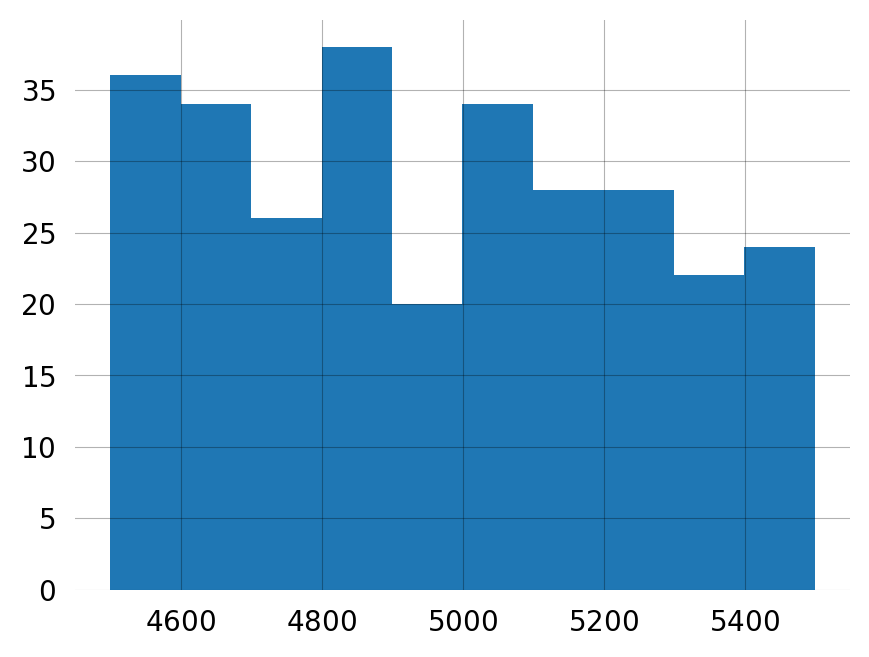

In [5]:
plt.hist(filtered_pairs.pos2 - filtered_pairs.pos1, bins=10) ;

In [6]:
# Konverter til obersvations-matrix
n = len(filtered_pairs)
observations = np.zeros((n, nr_samples), dtype=int)
observations
for i, pair in enumerate(filtered_pairs[["count1", "count2"]].values):
    observations[i, pair] = 1

In [7]:
msg = f"""
Two-locus observations across {nr_samples} samples of {seq_length/1e6:.0f} Mb:
    Mutation rate:
        {mut_rate} events/site/generation
    Recombination rate:
        {rec_rate} crossovers/base/generation
    Haploid population sizes:
        pop1: {pop1_size}
        pop2: {pop2_size}
    Migration rate:
        pop1 -> pop2: {migr_pop1_to_pop2}
        pop2 -> pop1: {migr_pop2_to_pop1}
"""
print(msg)


Two-locus observations across 5 samples of 100 Mb:
    Mutation rate:
        5e-10 events/site/generation
    Recombination rate:
        1e-08 crossovers/base/generation
    Haploid population sizes:
        pop1: 20000
        pop2: 10000
    Migration rate:
        pop1 -> pop2: 0.0001
        pop2 -> pop1: 0.0005



## 2. Bavian data

Jeg bruger det fulde kombinerede dataset fra GOG og Filoha, alle individer fra begge populationer for at maksimere statistisk styrke i two-island analysen.

In [8]:
# Indlæs data
ds = sg.load_dataset("/faststorage/project/baboondiversity/data/PG_panu3_phased_chromosomes_4_7_2021_ZARR/chr20.phased.rehead.vcz")

# Alle GOG og Filoha individer
pop1_ids = [
    'PD_0720', 'PD_0721', 'PD_0722', 'PD_0723', 'PD_0724', 'PD_0725', 'PD_0726',
    'PD_0727', 'PD_0728', 'PD_0729', 'PD_0730', 'PD_0731', 'PD_0732', 'PD_0733',
    'PD_0734', 'PD_0735', 'PD_0736', 'PD_0737', 'PD_0738', 'PD_0739', 'PD_0740',
    'PD_0741', 'PD_0742', 'PD_0743', 'PD_0744'
]  # GOG: P. anubis

pop2_ids = [
    'PD_0696', 'PD_0697', 'PD_0698', 'PD_0699', 'PD_0700', 'PD_0701', 'PD_0702',
    'PD_0703', 'PD_0704', 'PD_0705', 'PD_0706', 'PD_0707', 'PD_0708', 'PD_0709',
    'PD_0710', 'PD_0711', 'PD_0712', 'PD_0713', 'PD_0714', 'PD_0715', 'PD_0716',
    'PD_0717', 'PD_0718', 'PD_0719'
]  # Filoha: P. hamadryas

keep = pop1_ids + pop2_ids
mask = ds["sample_id"].isin(keep).values
ds_sub = ds.isel(samples=mask)

nr_samples_baboon = ds_sub.dims["samples"]
print(f"GOG:    {len(pop1_ids)} individer")
print(f"Filoha: {len(pop2_ids)} individer")
print(f"Total:  {nr_samples_baboon} individer")

GOG:    25 individer
Filoha: 24 individer
Total:  49 individer


/tmp/ipykernel_2844986/2124416127.py:23: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  nr_samples_baboon = ds_sub.dims["samples"]


## 3. Two-island model: 

Jeg tilpasser nu two-island modellen til de fulde bavian-data. Modellen estimerer migrationraterne i begge retninger under antagelsen om, at populationerne aldrig har været adskilt.

In [ ]:
# Beregn derived allele counts og udtræk SNP-par
variant_allele_counts = sg.count_variant_alleles(ds_sub)
ac = variant_allele_counts["variant_allele_count"].values

df_baboon = pd.DataFrame({
    "pos":   ds_sub["variant_position"].values,
    "count": ac[:, 1],
}).sort_values("pos").reset_index(drop=True)

# Segregerende varianter
df_baboon = df_baboon[(df_baboon["count"] > 0) & (df_baboon["count"] < nr_samples_baboon)]

# SNP-par
pairs_idx = pairs_in_range(df_baboon["pos"].values, distance-tolerance, distance+tolerance)
pairs_baboon = pd.DataFrame(
    [(df_baboon.at[i,"pos"], df_baboon.at[j,"pos"],
      df_baboon.at[i,"count"], df_baboon.at[j,"count"])
     for i, j in pairs_idx],
    columns=["pos1", "pos2", "count1", "count2"]
)

n_obs = len(pairs_baboon)
observations_baboon = np.zeros((n_obs, nr_samples_baboon), dtype=int)
for i, (c1, c2) in enumerate(pairs_baboon[["count1", "count2"]].values):
    if c1 < nr_samples_baboon: observations_baboon[i, int(c1)] = 1
    if c2 < nr_samples_baboon: observations_baboon[i, int(c2)] = 1

print(f"Segregerende varianter: {len(df_baboon):,}")
print(f"SNP-par (afstand ~{distance} bp): {n_obs:,}")
print(f"Observations-matrix: {observations_baboon.shape}")

In [ ]:
# Two-island model
graph_island = Graph()

graph_island.add_population("pop1")   # GOG
graph_island.add_population("pop2")   # Filoha

# Konstant migration — ingen split
graph_island.add_migration("pop1", "pop2", rate="m12")
graph_island.add_migration("pop2", "pop1", rate="m21")

priors_island = PropertySet(
    m12=HalfCauchyPrior(1e-4),   # Migration GOG → Filoha
    m21=HalfCauchyPrior(1e-4),   # Migration Filoha → GOG
)

print("Two-island model klar med parametre:")
print("  m12: migrationrate GOG → Filoha")
print("  m21: migrationrate Filoha → GOG")

In [ ]:
# Kør inferens
result_island = graph_island.fit(
    observations=observations_baboon,
    priors=priors_island,
    optimizer=Adam(
        step_size=ExpStepSize(0.05),
        regularization=ExpRegularization(1e-3)
    ),
    steps=500
)

print("Two-island model resultater")
print(result_island)

In [ ]:
# Visualiser posterior for migrationraterne
fig, ax = plt.subplots(figsize=(7, 4))

if hasattr(result_island, 'samples'):
    if 'm12' in result_island.samples:
        sns.kdeplot(result_island.samples['m12'], ax=ax,
                    label='m12: GOG → Filoha', color='C0')
    if 'm21' in result_island.samples:
        sns.kdeplot(result_island.samples['m21'], ax=ax,
                    label='m21: Filoha → GOG', color='C1')

ax.set_xlabel("Migrationrate")
ax.set_ylabel("Tæthed")
ax.set_title("Posterior fordeling af migrationrater\n(Two-island model, bavian-data)")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Samlet modelsammenligning: alle tre modeller

Jeg sammenligner nu alle modeller fra Notebooks 05–06. For at se hvilken model passer bedst til bavianernes genetiske data.

Antallet af parametre varierer fra de tre modeller:

- Two-island: 2 parametre ($m_{12}, m_{21}$)
- IM-model: 3 parametre ($T_{split}, m_{12}, m_{21}$)
- Ghost-model: 3 parametre ($T_{anc}, T_{admix}, p$)

In [ ]:
# Sammenligning, forudsætter at result_im og result_ghost er tilgængelige fra Notebook 05
# Kør Notebook 05 inden dette afsnit, eller sæt log-likelihood-værdier manuelt

models = {
    "Two-island": {"llk": result_island.log_likelihood, "n_params": 2},
}

# Tilføj IM og ghost hvis tilgængelige
try:
    models["IM-model"] = {"llk": result_im.log_likelihood, "n_params": 3}
    models["Ghost-model"] = {"llk": result_ghost.log_likelihood, "n_params": 3}
except NameError:
    print("Kør Notebook 5 for at inkludere IM- og ghost-modeller i sammenligningen.")

print("=== Samlet modelsammenligning ===")
print()
print(f"{'Model':<15} {'Log-likelihood':>16} {'Parametre':>12} {'AIC':>10}")
print("-" * 58)
for name, vals in models.items():
    aic = 2 * vals['n_params'] - 2 * vals['llk']
    print(f"{name:<15} {vals['llk']:>16.2f} {vals['n_params']:>12} {aic:>10.2f}")

print()
print("AIC (Akaike Information Criterion) straffer modeller for ekstra parametre.")
print("Lavere AIC = bedre model givet dataenes kompleksitet.")

In [ ]:
# Visualiser sammenligning hvis alle tre modeller er tilgængelige
if len(models) == 3:
    model_names = list(models.keys())
    llk_vals = [models[m]['llk'] for m in model_names]
    aic_vals = [2 * models[m]['n_params'] - 2 * models[m]['llk'] for m in model_names]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

    colors = ['C0', 'C1', 'C2']
    ax1.barh(model_names, llk_vals, color=colors, alpha=0.7)
    ax1.set_xlabel("Log-likelihood")
    ax1.set_title("Log-likelihood per model\n(højere = bedre fit)")

    ax2.barh(model_names, aic_vals, color=colors, alpha=0.7)
    ax2.set_xlabel("AIC")
    ax2.set_title("AIC per model\n(lavere = bedre givet parameterantal)")

    plt.tight_layout()
    plt.show()